# Report Project Basic of Mobile Robotics Team 20
## Table of content

1. [Members of the Group and Their Tasks](#1-members-of-the-group)
2. [Introduction](#2-introduction)
3. [Modules Implementation](#3-modules-implementation)
    - [Vision](#vision)
    - [Global Navigation](#global-navigation)
    - [Local Avoidance](#local-avoidance)
    - [Filtering](#filtering)
    - [Motion Control](#motion-control)
4. [Project Execution](#4-project-execution)
5. [Conclusion](#5-conclusion)
6. [References](#6-references)

## 1. Members of the Group
- **Mathieu Bornet, 341672**: Vision (Open CV) and main architecture.
- **Pierre Emmel, 362005**: Global navigation (A* algorithme) and report.
- **Christophe Huynh, 362542**: Local avoidance and motion control.
- **Lukas Nyholm, 415573**: Filtering (Extended Kalman Filter).

## 2. Introduction

**Environment**

We choose a free environnement (meaning we don't use a fixed map to test our program). We decide to take 4 Aruco markers to help us to delimitate our map, to detect the goal and the Thymio robot (that is also the start at the begining). For the obstacle we use printed black forms (various forms are possible it is not limited to convex forms). Since the map is tunable, we can change the position of the obstacles amd also add or remove some. The project can be executed in various locations thanks to this settings. The use of aruco markers and black color is robust to a luminosity change. The only condition is that the background isnt dark to have a sufficient contrast between the obstacles and the background. For our demonstration we decided to use a fixed map as showed below :


<div style="text-align: center;">
    <img src="figures/filtered_nice.png" alt="Figure 1: Picture of our map for the demonstration" width="800">
    <p><strong>Figure 1:</strong> Picture of our map for the demonstration</p>
</div>


**Choices we made and overall view**

For the **Overall architecture**, we use Python classes to keep modules well defined and improve performance by preferring attributes over excessive local variables. The main program implements a state machine to detect different situations and execute the required actions.

We used **OpenCV**[1] for the Vision module because it was covered in the lectures and provides a comprehensive image-processing library.
The captured frames are converted into a **grid of cells**. We chose this representation to support non-convex obstacles and to keep the map easily configurable. 

The grid uses square cells so that horizontal and vertical distances are measured with the same scale. **Square cells** prevent geometric distortion, make distance and angle computations (including diagonal moves) consistent, and simplify conversion between grid units and physical units (cm). This ensures correct heuristics and path costs for the planner and keeps motion-control calculations simpler and more robust.

To compute the global path we use the **A* algorithm**. A* is efficient for our grid representation and returns a single optimal path, which is sufficient for our needs. The planned path is converted into a sequence of **displacement vectors** between consecutive cells. Motion control and the filter use these vectors to drive the robot.

If a new obstacle appears on the planned path, the state machine switches to a **local-avoidance state**. While in this state, the Thymio ignores the remaining global vectors until its proximity sensors no longer detect the obstacle. We also apply a timeout threshold to give the robot a short interval to return to the global path before replanning.

To obtain an accurate pose estimate we use an **Extended Kalman Filter (EKF)** for sensor fusion because the robot's motion model is nonlinear. The EKF fuses odometry-based motion (given robot velocity) with camera-based pose measurements. This combination reduces odometry drift, filters measurement noise, and provides a consistent estimate used by the motion control. Process and measurement covariances were tuned empirically to reflect sensor noise and update rates.

**Use of AI**: We used AI to help us programming the general form of each class, most of us never used it in python. It was easier to understand how a constructeur works and how to use privat/public variables or methods in a class. 

## 3. Modules Implementation

### Global architecture

**Choices we made**: For the global architecture of our project, we decided to use classes in python. Each file correspond to a module, we have classes for the vision, the global navigation, filtering and motion control to use it with his variables. Since local avoidance as a few function and don't need to much variables we didn't created a class for it. Using classes helped us to implement each module together. For instance the class for vision register the start, goal and grid used furthermore by the global navigation to compute the optimal path : 
```python
gnav.set_gnav(v)
```
In this code line we set the variables of the global navigation class given by the vision (object v). Each class is imported in the main : 
```python
from vision import Vision
```
The classes are initialized at the start of the main like following : 

```python
v = Vision()
gnav = GlobalNavigation()
mc = await Motion_control.create() #Motion Control
```

The filtering class is initiaalized in the Montion Control class : 
```python
self.ekf = Filtering()
```
Beside the classes we have a two parts architecture to manage the output and inputs between the Thymio robot, the camera and the differents files. Our main file manages the differents states in our programm and the motion control manages the robot by calling itself, the filtering and the local avoidance. 

<div style="display:flex;flex-direction:column;align-items:center">
  <div style="display:flex;gap:18px;justify-content:center;align-items:flex-start;">
    <figure style="margin:0;text-align:center;">
      <img src="figures/file_structure.png" alt="Filtered 1" style="width:600px;height:auto;border-radius:4px;">
    </figure>
    <figure style="margin:0;text-align:center;">
      <img src="figures/legend_file structure.png" alt="Filtered 2" style="width:400px;height:auto;border-radius:4px;">
    </figure>
  </div>
  <figcaption style="margin-top:8px;text-align:center;font-size:0.95em;">
    Figure 2 - Module connection with inputs and outputs.
  </figcaption>
</div>

We use a Finite State Machine in our main.py to manage the different steps in our program :

<div style="text-align: center;">
    <img src="figures/FSM.png" alt="Figure 3" width="800">
    <p><strong>Figure 3:</strong> State diagram from our Finite State Machine</p>
</div>

First, when the program starts or after a kidnapping, the system enters the GRID_CREATION state. In this state the Vision and GlobalNavigation modules are initialized. We capture and filter an image, crops and rectifies it using the border ArUco markers, then builds an occupancy grid. The A* planner computes a global path on the inflated (robot-sized) grid; the resulting path is converted into displacement vectors and Cartesian waypoints. The EKF (filtering) is initialized from the detected robot pose and its covariance. Variables such as step_count and cm_to_pixel are also set. If no valid path is found the program logs the error.

Next the program enters GLOBAL_NAVIGATION, the main navigation loop. Each iteration it acquires the latest camera pose ($x, y, \theta$) and updates the filter/estimate. The current target waypoint is taken from the precomputed path and converted into a displacement (distance, heading). Motion control (mc.fsm) is called with that target; mc.fsm sends motor commands and handles local avoidance. We use an index called step_count to track the robot's progress along the path. At each main-loop iteration the controller compares the robot's estimated position to the current waypoint. When the waypoint is considered reached (within the goal tolerance or a waypoint-specific threshold), step_count is incremented so the next waypoint becomes the active target. If a local avoidance manoeuvre occurs, the main loop can advance step_count by SKIP_STEPS to skip several intermediate waypoints and rejoin the global path ahead of the obstacle. This simple index-based mechanism keeps the main controller synchronized with motion control, handles small overshoots or temporary diversions without immediate replanning, and makes resuming global navigation straightforward.

If the robot is not detected on camera and the ground sensors indicate it has been lifted, the program moves to KIDNAPPING. If motion control detects a local obstacle it reports to the OBS_AVOIDED state. The main loop then advances step_count by SKIP_STEPS to bypass a few waypoints and resume GLOBAL_NAVIGATION. When the estimated pose is within GOAL_EPS_CM of the final goal the state changes to GOAL_REACHED.


OBS_AVOIDED is a short/transient state: after local avoidance the code advances the waypoint index (SKIP_STEPS) to safely rejoin the global path and returns to GLOBAL_NAVIGATION.

KIDNAPPING: on entry the program stops the motors and closes windows. It repeatedly checks vision until the Thymio is detected again. Once detected it waits a short delay (≈3 s), clears buffers, and returns to GRID_CREATION to rebuild the grid and recompute the path.

GOAL_REACHED: stop motors, close resources/windows, optionally plot position comparisons, and exit the main loop.
  
  

### Vision
#### General architecture ####
First of all, we manage the vision of our map using the OpenCV and numpy libraries. And for some plots we used matplotlib.

Concerning the general choices/norms used in this part:
- To concentrate the vision effort in the interesting zone two Arucos have been used (Arucos with id 0 and 2). The vision will crop a rectangle with its edges passing by those Arucos's centers.
- The thymio position and its angle is detected thanks to the Aruco number 1 and the goal is detected with the Aruco number 3 which makes it completely movable.
- The norm used in the grid creation is the following: 0 = road, 1 = walls.
- To clean our frames, we used a bilateral filter since it manages to smooth the image while conserving the edges. There is of course a tradeoff in terms of computation time but since we have time to do it it is a good solution (i.e. sampling time not too short).
- As said before, after the filtering, the frame is cut to only keep the interesting part. While doing this, there is also a perspective transformation applied to obtain a frontal/orthogonal view. With this, the frame can then be used to pass from pixels to cm easily (and it is a better frame for visualizing). Since it is not perfect, the pixels per cm varies a bit but it is sufficient for this project. And the position will be shifted with the same range so if the goal is shifted a bit to the right => the position of the robot close to this will be shifted too by the same amount.

Since this system is using Arucos to detect the thymio and the goal and that the obstacles are in black. There is a need to not take into account those Arucos as obstacles otherwise the map would be wrong. Our method is to replace the Arucos with white on the frame which will be used in the creation of the grid (with a margin).

**Remark:** How the main parts are done is described below (the logic in the choice part and actually how it is done in the code part)

#### Main flow diagram ####
The vision part is used as follow:
In the init of the class the camera is "connected" and initialized. Afterwards, the main function to create the grid is called "vision". In this function the flow is the following:
- Get the filtered frame
- Cut it with the Arucos 0 and 2 and do the perspective change
- Create the grid by doing a threshold on a gray scale converted frame (this threshold can be used to tune the vision if the environment changed, i.e. amount of light...). This method is sufficient since we just have black or white on the map (and not colors).
- (If needed, due to the environment -> an expansion can be done on the obstacles. But, the main "safety expansion" in our workflow is done in the global navigation part).
- Also, this method will calculate the goal and thymio position which will be used by global navigation to create the global path.
Remark: the "vision" method does not return anything but global navigation will go search for the attribute it needs.

During the main: 
- Since motion control needs to have the angle of the robot at time t. A method has been done to return the angle in rad between -pi and pi. It has been done by detecting the Aruco orientation number 1.
- Since motion control works in cm, a method has been done to return positions in cm (and the angle).

#### Main choices ####
**Bilateral filtering**

In the step of getting a frame with the camera a filtering has been done to clean the frame. The python library OpenCV has been used to do a bilateral filtering as follows: cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace).
The parameters means the following:
- d = neighborhood diameter = It tells OpenCV how big the area around each pixel should be when computing the filter. 
    - small d => only nearby pixels are used 
    - large d => more distant pixels are also used
- sigmaColor = How much influence the difference in color/intensity has during filtering. 
    - A larger sigmaColor → pixels with very different colors will still influence each other → stronger smoothing across edges (i.e. weaked edge preservation)
    - A smaller sigmaColor → only similar-colored pixels affect each other → preserves edges better.
- sigmaSpace = How much influence spatial distance has (i.e. How quickly does influence decrease with distance ?).
    - Large sigmaSpace → distant pixels (within d) influence each other → smoother, more global effect.
    - Small sigmaSpace → only very close pixels matter → more localized filtering.

Our final choice is the following: cv2.bilateralFilter(frame, d=-1, sigmaColor=25, sigmaSpace=7)
- d = -1 causes OpenCv to take the best value which is often better than a man made choice.
- SigmaColor 25 is a good compromise between to much noise impact and a good edge detection
- sigmaSpace 7 is good since the picture is 480 x 640. So this value is wide enough to smooth local noise while remaining spatially localized.

**Arucos**

The logic behind using arucos is that it is robust and easy to implement (a lot of examples and functions online). They have been used for the following:
- To cut the frame -> the center of the arucos 0 and 2 are detected and the frame is cut in a rectangle set by those centers.
- To know the conversion between pixels and cm in the cut frame -> the two not cropped remaining arucos (thymio and goal) are used to calculate the conversion. Since, the size of the arucos are constant and known (5 cm) it is then possible to find the size in pixels of those two arucos and to convert it to cm. There is a small distortion in distance due to the fact that the homography is not perfect. But as said before it is clearly enough for this project.
- The aruco which is on the thymio is used to detect the robot position (i.e. the center of the aruco) but also the orientation. To calculate the orientation, the difference between the center and the top right corner is used. This works well since the aruco has a precise orientation and the detected corners are always sorted in the right orientation. Due to that method the aruco which is put on the thymio needs to be put in the right orientation with its right corner facing the front of the robot.

To detect the Arucos the CV2 arucos library has been used, it stores the arucos models. Then, the parameters object is created. They could be modified but here the default parameters have been used. After that, the detector object is created and used to actually detect the arucos. After detecting them, their corners positions is stored and their ids too (to be able to identify which aruco is with which corners). 
The code to detect the Arucos is the following:
```python
#Convert the image to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()

#Create the ArUco detector
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
#Detect the markers
corners, ids, rejected = detector.detectMarkers(gray)
```
Remark: rejected contains the contours which are close to be arucos but did not pass the verification (it can be useful for debug).

**Homography**

This part cuts the frame inside the borders Arucos and do a transformation to "face the frame". To do this, the code create a box which is the border of the cropped frame and create a homography matrix M.
The logic behind M is that it links the position between the "real frame" and the new cropped frame.
$$
M =
\begin{bmatrix}
a & b & c \\
d & e & f \\
g & h & 1
\end{bmatrix}
$$

$$
x' = \frac{ax + by + c}{gx + hy + 1}
$$

$$
y' = \frac{dx + ey + f}{gx + hy + 1}
$$
With x' and y' being the position in the new cropped frame. So, to create the new frame and do the homography, this function: cropped_frame = cv2.warpPerspective(frame, self._M, (self._w, self._h), borderMode=cv2.BORDER_REFLECT) does the following:
- Step 1, OpenCV creates an empty frame of size self._w x self._h
- Step 2, For each pixels in the new frame, it finds which pixel it is in the original frame: $$ (x,y) = M^{-1}*(x',y')$$
- Step 3, Take its value with an bilinear interpolation to try to not have noise. This interpolation is necessary since the (x,y) position will fall often between pixels and not exactly on one -> filtering to take an weighted average.
- Step 4, Write it in the cropped frame

Remarks:
- To not have to redo each time the detection of the borders arucos and the computation of the box and M, those parameters are solve in the vision class. Since the camera and the border arucos are not moving it is a good solution (the code has a parameter which can permit to recalculate if wanted)
- The BORDER_REFLECT parameter is used if the cropped frame tries to take the value of a pixel outside of the origin frame which is not used in our case (i.e. the cropped frame is always inside the real frame).


#### Main flow diagram in pictures ####
This part shows the main logic behind the vision with screens of the plot functions.


-In the get frame process -> filtering
<div style="text-align: center;">
  <figure style="margin:0; text-align:center;">
    <img src="figures/filtered_nice.png" alt="Filtered 2" style="width:360px; height:auto; border-radius:4px;">
    <figcaption style="font-size:0.9em">Figure 6: Filtered</figcaption>
  </figure>
</div>
- In the call to the vision function which will create the grid. Some frames are taken and forgotten to do an "anti-yellow" frame.
<div style="text-align: center;">
    <img src="figures/yellow_image.png" alt="Figure 9: Image of the map before the anti yellow" width="400">
    <p><strong>Figure 9:</strong> Image of the map before the anti yellow</p>
</div>
- In the grid creation -> replace the arucos with white squares
<div style="text-align: center;">
    <img src="figures/cropped_with_white.png" alt="Figure 4: Cropped part with white Aruco markers" width="400">
    <p><strong>Figure 4:</strong>Cropped part with white Aruco markers</p>
</div>
- The grid reconstruction
<div style="text-align: center;">
    <img src="figures/grid_white_black.png" alt="Figure 8: Grid with white and black" width="400">
    <p><strong>Figure 8:</strong> Grid with white and black</p>
</div>
-Proof of the fact that the grid is made of square cells
<div style="text-align: center;">
    <img src="figures/grid_frame.png" alt="Figure 7: Grid Frame" width="400">
    <p><strong>Figure 7:</strong> Grid Frame</p>
</div>

#### Main issues that happened ####
A big issue was that the general path was wrong in the x axis. The reason for that was that the grid was not made of squares (in cm). But, the global navigation was taking it as square. To change that, the get_grid function has a mode to not have the user to fix Nx and Ny (the grid size) but just fix an amount of pixels and the function will create a squared grid cell with this amount of pixel in each cells. Another way to do it could have been to take this non uniformity into account in the global navigation part (in the distance/steps calculation).

Also, sometimes, the thymio was lost (i.e. its aruco). This was due to the fact that the lightning was not always perfect and that the contrast was not perfect with the aruco on top of the thymio. An easy fix which works well is to print the Arucos with a small white border on the sides (i.e. not cut them at the end of the black regions <=> at the end of the aruco itself). Doing that the contrast is better and constant between the aruco drawing and its white part. After that there has never been this situation again.

#### Interesting code parts ####
This chapter has some parts of the code which are the most "important/difficult" parts.

**Camera initialization:** 
The 0 may need to be change if others camera are connected to the computer.
```python
#Open camera (0 = first camera USB detected)
self.__cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
```

**Get frame and filter it:**
```python
#Read one frame
ret, frame = cap.read()

if not ret:
    raise Exception("Unable to capture the image")

frame = cv2.bilateralFilter(frame, d=-1, sigmaColor=25, sigmaSpace=7) #filtering
```

**Aruco detection:**
```python
#Convert the image to grayscale
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
parameters = cv2.aruco.DetectorParameters()

#Create the ArUco detector
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
#Detect the markers
corners, ids, rejected = detector.detectMarkers(gray)
```

**Example of important usage with the code above -> detect the center and the angle of aruco id 1:**
```python
#Find aruco with id 1 (thymio)
thymio_idx = None
thymio_corners = None

for idx, marker_id in enumerate(ids):
    if marker_id[0] == 1:
        thymio_idx = idx
        thymio_corners = corners[idx]
        break

if thymio_idx is None:
    print("Aruco id 1 (thymio) not detected")
    return None, None, None

#Get the center of the aruco
pts = thymio_corners[0]  #shape (4,2) - [top-left, top-right, bottom-right, bottom-left]
center = pts.mean(axis=0)
x, y = center[0], center[1]

#Calculate orientation from center to top-right corner
#pts[1] is the top-right corner
top_right = pts[1]
dx = top_right[0] - x
dy = top_right[1] - y
angle = np.arctan2(dy, dx)
```

**Another important example -> to know the factor between pixels and cm (where aruco_real_size_cm is the real size of the Aruco which, for our case, is 5cm):**
```python
#Compute mean pixel size of detected ArUco to get scale
aruco_pixel_sizes = []
for c, i in zip(corners, ids):
    pts = c[0]
    pixel_width = np.linalg.norm(pts[0] - pts[1])
    pixel_height = np.linalg.norm(pts[1] - pts[2])
    aruco_pixel_sizes.append((pixel_width + pixel_height) / 2)

if len(aruco_pixel_sizes) > 0:
    mean_pixels = np.mean(aruco_pixel_sizes)
    if mean_pixels > 0:
        #Number of pixels per cm
        cm_to_pixel = mean_pixels / self._aruco_real_size_cm
```

**The last very important bit of code is where the cutting of the frame is done:**
```python
#Remark: centers_2pts are the centers of the two Arucos who are delimiting the box
def get_frame_from_aruco(self,frame,plot=False):
    ...
    #Ensure ArUco 0 is at bottom-left and ArUco 2 is at top-right
    #We need to determine which one is actually bottom-left vs top-right
    center_0 = centers_dict[0]
    center_2 = centers_dict[2]

    #Determine which center should be bottom-left (min x, max y) and top-right (max x, min y)
    #Compare both centers to determine orientation
    if center_0[0] < center_2[0] and center_0[1] > center_2[1]:
        #ArUco 0 is correctly bottom-left, ArUco 2 is top-right
        bottom_left_center = center_0
        top_right_center = center_2
    elif center_0[0] > center_2[0] and center_0[1] < center_2[1]:
        #ArUco 0 is actually top-right, ArUco 2 is bottom-left (flipped)
        bottom_left_center = center_2
        top_right_center = center_0

    #Build the 4 corners of the rectangle: [top-left, top-right, bottom-right, bottom-left]
    #top-left: min x, min y
    #top-right: max x, min y
    #bottom-right: max x, max y
    #bottom-left: min x, max y
    top_left = np.array([bottom_left_center[0], top_right_center[1]])
    top_right = top_right_center
    bottom_right = np.array([top_right_center[0], bottom_left_center[1]])
    bottom_left = bottom_left_center

    #[top-left, top-right, bottom-right, bottom-left]
    centers = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

    cropped_frame,M = self.cut_from_aruco(frame,centers)
    ...

def cut_from_aruco(self,frame,centers):
'''
Do the cut and return the cropped frame and the transformation matrix
+ applies perspective transformation to obtain a frontal/orthogonal view
and do a borderMode to reduce distortion at the edges
'''
#centers is already ordered as [top-left, top-right, bottom-right, bottom-left]

#Calculate actual distances between corners to preserve aspect ratio
self._w = int(np.round(np.linalg.norm(centers[1] - centers[0])))
self._h = int(np.round(np.linalg.norm(centers[3] - centers[0])))

if self._w == 0 or self._h == 0:
    print("Invalid rectangle dimensions for cropping.")
    return None

#Destination points in the same order: [top-left, top-right, bottom-right, bottom-left]
dst_pts = np.array([[0,0],[self._w,0],[self._w,self._h],[0,self._h]], dtype="float32")

#Transformation
self._M = cv2.getPerspectiveTransform(centers, dst_pts)
cropped_frame = cv2.warpPerspective(frame, self._M, (self._w, self._h), borderMode=cv2.BORDER_REFLECT)#Apply borderMode to reduce distortion at the edges (should not be used)
return cropped_frame,self._M
```


### Global Navigation

#### Overview

The global navigation system implements the A* pathfinding algorithm on our grid-based representation of the environment . We compute the optimal path using a diagonal distance (8-cells decomposition) with an adapted heuristic function. The robot navigates from the start position to the goal position while avoiding obstacles, we take into account the physical dimensions of the Thymio robot to ensure a collision-free path. For that we growth each obstacles by half the diameter of the Thymio robot (so it can turn around it self and don't touch an obstacle).

#### Choices mades

We took the A* algorithm for his efficiency and low computation. Also we didn't wanted to take all the possible optimal paths on our map and that we take only one in account. A diagonal distance gives more possibility on a grid-based map since a Manhattan distance would be limitting and some paths impossible. To perform the pathfinding algorithm we decided to take one path using each time one cell and to growth the obstacles on our grid to avoid collisions. This approach didn't modified the heart of the A* algorithm and computing the growth of obstacles was easily implemented with a function. Finally the grid resolution (numbers of cells) is determined by the vision, the only condition was to have a square grid map. For that we needed a number of cells adapted to the size of the image (this step is performed by the [vision module](#vision)). Taking to much cells took too much time. For that we used a range that worked well and had enough cells to have a good map descriptions (no obstacles that takes to much places).

#### Obstacle Growing

To guarantee collision-free navigation we account for the Thymio's physical size by inflating obstacles on the grid. By growing obstacles by the robot's radius (in grid cells) we can treat the robot as a point (its center) for path planning while ensuring a safe margin to the real obstacle edges.

The size of the Thymio (width × length) is about 11.0 cm × 11.2 cm. The safety diameter we use is the diagonal of that rectangle (so that the Thymio can turn around itself without touching an obstacle):

$$d = \sqrt{11.0^2 + 11.2^2} \approx 15.7\ \text{cm}$$

$d$ is rounded up to 16 cm for safety. To convert this physical size to grid cells we compute the robot radius in cells (rounded up with np.ceil from numpy library):
- $ thymio_size = thymio_radius = d / 2 = 8 cm$
- robot_size = np.ceil(radius_cm / cell_size)


This gives the number of cells to grow around each obstacle. The robot occupies a square of side length `2 * robot_size + 1` cells on the grid (center cell plus `robot_size` cells in each direction).

Algorithm :
1. Compute `robot_size` as above.
2. Create a copy of the original grid.
3. For every obstacle cell (value = blocked) in the original grid, mark all neighbors within the square offset range `[-robot_size, ..., +robot_size]` as obstacles in the copied grid.
4. Use the expanded grid for A*.

Implementation in Python : 

```python
def growing_obstacles(self):
        
        modified_grid = np.copy(self.grid)

        for i in range(len(self.grid)):
            for j in range(len(self.grid[0])):
                
                if self.grid[i][j] == 0:  
                    
                    for di in range(-self.robot_size, self.robot_size+1):
                        for dj in range(-self.robot_size, self.robot_size+1):
                            
                            ni = i + di
                            nj = j + dj
                            if 0 <= ni < len(self.grid) and 0 <= nj < len(self.grid[0]):
                                modified_grid[ni][nj] = 0 # adding obstacles

        self.grid = modified_grid

```

#### Heuristic Function

The heuristic function is a key component of the A* algorithm, providing an estimate of the remaining cost from any cell to the goal. We implemented the **diagonal distance heuristic**, also known as Chebyshev distance (adapted for 8-directional movement).

1. Setup : 

For two points $a$ and $b$ in a grid where diagonal movement is allowed, we define:
- $\Delta_x = |a_x - b_x|$ : the horizontal distance
- $\Delta_y = |a_y - b_y|$ : the vertical distance  

We also define the movement costs:
- $D = 1$ : the cost of orthogonal movement
- $D_2 = \sqrt{2}$ : the cost of diagonal movement

2. Derivation :

The optimal strategy is to use diagonal moves as much as possible, since they cover two dimensions simultaneously. The number of diagonal moves is $\min(\Delta_x, \Delta_y)$, as we want to maximize diagonal movement. The remaining displacement is orthogonal and corresponds to $\max(\Delta_x, \Delta_y) - \min(\Delta_x, \Delta_y)$. Therefore, our heuristic is initially defined as:

$$h(a, b) = D \cdot \left(\max(\Delta_x, \Delta_y) - \min(\Delta_x, \Delta_y)\right) + D_2 \cdot \min(\Delta_x, \Delta_y)$$

Expanding this expression:

$$h(a, b) = \max(\Delta_x, \Delta_y) \cdot D + \min(\Delta_x, \Delta_y) \cdot (D_2 - D)$$

Using the algebraic identity $\max(\Delta_x, \Delta_y) = (\Delta_x + \Delta_y) - \min(\Delta_x, \Delta_y)$
We obtain the final form:

$$h(a, b) = (\Delta_x + \Delta_y) \cdot D + \min(\Delta_x, \Delta_y) \cdot (D_2 - 2D)$$

This heuristic is **admissible** (never overestimates the actual cost) and **consistent**, making it suitable for A* pathfinding with diagonal movements. The implementation of this heuristic follows the approach presented in a Standford paper [2].

#### A* Pathfinding Algorithm

The A* algorithm finds the optimal path by maintaining a priority queue of cells to explore, ordered by the estimated total cost $f(n) = g(n) + h(n)$, where $g(n)$ is the cost from start to cell $n$ and $h(n)$ is the heuristic estimate to the goal (See heuristic function above). We based our implementation on the implementation in Exercice 5. 

- Inputs : 
    - `grid`: 2D array representing the map (0 = obstacle, non-zero = traversable)
    - `start`: starting position (row, col)
    - `goal`: target position (row, col)

- Outputs : 
    - `path`: list of positions from start to goal
    - `explored`: set of all visited cells

- Initialization : 
    - g_costs ← {start: 0} : Cost from start
    - came_from ← {} : Dictonnary of explored map
    - explored ← $\emptyset$ : Visited cells
    - open_set ← [(h(S,G), 0, S)] : Priority queue
    - S, G : Start and Goal

- Main loop : 

```
        while open_set $\neq \emptyset$
            (f, g, current) ← pop open_set
            add current to explored
            if current = G: break
            for each neighbor c of current (8-dir)      
                if c invalid or explored: skip
                cost ← g + ($\sqrt(2)$ if diagonal else 1)
                if cost < g_costs[c]
                    g_costs[c] ← cost
                    came_from[c] ← current
                    push (cost + h(c,G), cost, c) to open_set

```

- Backtracking : 
```
    current ← G
    path ← [G]

    while current $\neq$ S
        current ← came_from[current]
        append current to path

    reverse path
    return path, explored
```

####  Neighbor Exploration with Diagonal Movement

The algorithm explores eight neighbors for each cell: four orthogonal and four diagonal directions. current_pos is like a matrix so we need to take care how we compute the neighbors cells.

```python
neighbors = [
    (current_pos[0]-1, current_pos[1]),   # Up
    (current_pos[0]+1, current_pos[1]),   # Down
    (current_pos[0], current_pos[1]-1),   # Left
    (current_pos[0], current_pos[1]+1),   # Right
    (current_pos[0]-1, current_pos[1]-1), # Diagonal Up-Left
    (current_pos[0]-1, current_pos[1]+1), # Diagonal Up-Right
    (current_pos[0]+1, current_pos[1]-1), # Diagonal Down-Left
    (current_pos[0]+1, current_pos[1]+1)  # Diagonal Down-Right
]
```

#### Handling Diagonal Movement Costs

A key aspect of our implementation is correctly weighting diagonal versus orthogonal movements. Diagonal moves cover a distance of $\sqrt{2}$ compared to orthogonal moves, so $g(n)$ needs to be adapted :

```python
if is_diagonal: 
    move_cost = np.sqrt(2)  # Diagonal cost
else: 
    move_cost = 1  # Orthogonal cost 

tentative_g_cost = current_g_cost + move_cost
```

#### Cost Update and Path Reconstruction

For each valid neighbor, we update its cost if we've found a better path:

```python
if neighbor not in g_costs or tentative_g_cost < g_costs[neighbor]:
    g_costs[neighbor] = tentative_g_cost
    came_from[neighbor] = current_pos
    
    f_cost = tentative_g_cost + self.heuristic(neighbor, self.Goal)
    heappush(open_set, (f_cost, tentative_g_cost, neighbor))
```

Once the goal is reached, we reconstruct the path by backtracking through the `came_from` dictionary and return the path. When we plot the output we obtain the following result : 

<div style="text-align: center;">
    <img src="figures/path.png" alt="Figure 8: Example of result of A* algorithm on grid map" width="800">
    <p><strong>Figure 10:</strong> Example of optimal path with our A* algorithm (yellow path on grid map with start in red and goal in blue)</p>
</div>

#### Vector for Path Following

To enable the robot to follow the computed path, we convert the discrete grid path into a series of displacement vectors. Each vector is a tuple of the distance and angle (in the range $[-\pi, \pi]$) the robot must travel to reach the next point.

We compute the differences between consecutive path points to obtain displacement vectors:

```python
 def vectors_for_displacement(self, path) : 
        
        path = np.array(path)

        #[dy, dx] = [y[i+1] - y[i], x[i+1] - x[i]]
        delta = np.diff(path, axis = 0)

        #Norm between two cells in the center
        norm = np.linalg.norm(delta, axis = 1)

        #Give an angle [-Pi, Pi] with arctan(theta) = y/x
        angles = np.arctan2(delta[:, 0], delta[:, 1]) 

        #Convert norm in cm
        norm_cm = norm * self.cell_size
        
        #Give back a vector with a tuple (norm, theta)
        vector = list(zip(norm_cm, angles))
   
        return vector 
```

This output gives to motion control the possiblity to follow the path.


### Local Avoidance

The local avoidance manoeuvre is called when a obstacle is detected. Once the Thymio enters this avoidance state, it leaves the path following isntruction for the avoidance one. This part has been higly inspired by week 3 exercises.

#### Obstacle detection

We used the horizontal proximity sensors to detect if there is an obstacle close the front of the robot. If one of those sensors' output is geater than a threshold, the Thymio enter the obstacle avoidance state. In order to avoid the impact of measruement which might lead to detection-jittering, we implemented a hysteresis. That means that it is easier to enter the local avoidance state than to exit from it.

#### Avoidance manoeuvre
In a active obstacle avoidance, a neural network is used to calcuate the right motors speed to avoid an obsacle, based on sensor's outputs. This single layer assign to each horizontal proximity sensors a weight in a way that the more a obstacle is detected at the extremety of the sensor line, the more it has to deviate strongly since at extremeties, any deviation will make the obstacle undetectable, thus making the robot exit the avoidance routine to early. In addition, a memory of previous motor commands is implemented which allows the robot to still turning a bit even no more obstacle is detected. When an obstacle is detected closer to the middle of the sensor line, while deviating, the Thymio still detecting the obstacle. Thus, those sensors' weights can be less important. Also, the very middle sensor get a negative value, so that the robot drive backward.

After the active obstacle avoidance manoeuvre, the Thymio heads forward during 4 seconds to make sure that the obstacle has been overtaken. Then, to return to the path while avoiding steps that may be pathed in the local obsatcle. To avoid this, the next few steps are skipped. The numbers of steps to skip depends on the definition of the map grip. Actually, the more the map is meshed, the more the path is devided in steps, hence, the 

### Filtering - Extended Kalman Filter
#### The design
For the states of the robot, we choose the state vector $\textbf{x}=[x\; y\;\theta]^T$, where $x$ is the x-coordinate, $y$ is the y-coordinate, and $\theta$ is the angle of the Thymio.
<br>
When we want to know the coordinates of the robot we use the extended kalman filter(EKF). EKF is in two steps, 'Predict' step and 'Update' step. Our implementation of EKF is as follows.
<br>
First we initialize our estimated state vector $\hat{\textbf{x}}_{k|k}$ and our estimated covariance matrix $\textbf{P}_{k|k}$. The initial estimated state is set to be the same as the position measurements from the camera, to make sure the imaging and the fitler is working from the same reference point.
<br>
We have found our robot's sensor- and process noise covariances and encoder-to-m/s conversion factor before, in week 8 exercises, which is added into the code. Since the conversion factor made the robot move a bit too fast, we hand-tuned it slightly so it was more accurate. We did the same for the noise covariance matrices $Q$ and $R$. We avoided hand-tuning too much, in order to keep a more empirical approach.
<br>
Secondly we predict the states from odometry. If the camera measurements isn't available, for instance if the camera's vision is being blocked by something, then the estimated state is just the odometry.
<br>
Finally, if the camera measurements are available, then we update the states based on measurements.

#### Filter computations
**Predict step**, described mathematically:
+ State transition Jacobian $\mathbf{F}_k = \left. \frac{\partial f}{\partial x} \right|_{\hat{\mathbf{x}}_{k-1|k-1}, \mathbf{u}_{k-1}}$<br>
+ Predicted state $\hat{\textbf{x}}_{k|k-1} = f(\hat{\textbf{x}}_{k-1|k-1}, \textbf{u}_{k-1})$<br>
+ Predicted covariance $\textbf{P}_{k|k-1} = \textbf{F}_{k} \textbf{P}_{k-1|k-1} \textbf{F}_{k}^{T} + \textbf{Q}_{k-1}$<br>

In code:
```python
    def state_transition_jacobian(self):
        ''' Compute the derived Jacobian of the state space model
        Note: angle is negated because vision uses image coordinates (Y down)
        while our reference frame has Y up (origin bottom-left)'''
        return np.array([[1, 0, -self.v * np.sin(-self.x_prev[2]) * self.Ts],
                         [0, 1,  self.v * np.cos(-self.x_prev[2]) * self.Ts],
                         [0, 0, 1]])

    def predict_state_est(self):
        ''' Predict the next state and covariance'''
        if abs(self.omega) < 1e-9:
            # Angle negated for image coordinate system (Y down in images vs Y up in our frame)
            self.x_pred = np.array([
                        self.x_prev[0] + self.v * np.cos(-self.x_prev[2]) * self.Ts,
                        self.x_prev[1] + self.v * np.sin(-self.x_prev[2]) * self.Ts,
                        self.wrap_angle(self.x_prev[2] + self.omega * self.Ts)])
        else:
            # Angle negated for image coordinate system (Y down in images vs Y up in our frame)
            theta_neg = -self.x_prev[2]
            self.x_pred = np.array([
                        self.x_prev[0] + (self.v / self.omega) * (np.sin(theta_neg + self.omega * self.Ts) - np.sin(theta_neg)),
                        self.x_prev[1] + (self.v / self.omega) * (-np.cos(theta_neg + self.omega * self.Ts) + np.cos(theta_neg)),
                        self.wrap_angle(self.x_prev[2] + self.omega * self.Ts)])

        F = self.state_transition_jacobian()

        self.P_pred = F @ self.P_prev @ F.T + self.Q
```


**Update step**, described mathematically:<br>
+ Observation Jacobian $\mathbf{H}_k = \left. \frac{\partial h}{\partial x} \right|_{\hat{\mathbf{x}}_{k-1|k-1}}$<br>
+ Innovation $\tilde{\textbf{y}} = \textbf{z}_{k} - h(\hat{\textbf{x}}_{k|k-1})$<br>
+ Innovation covariance $\textbf{S}_k = \textbf{H}_k \textbf{P}_{k|k-1} \textbf{H}_{k}^{T} + \textbf{R}_k$<br>
+ Near-optimal Kalman gain = $\textbf{K}_k = \textbf{P}_{k|k-1} \textbf{H}_{k}^{T} \textbf{S}_{k}^{-1}$<br>
+ Updated state $\hat{\textbf{x}}_{k|k} = \hat{\textbf{x}}_{k|k-1} + \textbf{K}_k \tilde{\textbf{y}}_{k}$<br>
+ Updated covariance $\textbf{P}_{k|k} = (\textbf{I} - \textbf{K}_k \textbf{H}_k)\textbf{P}_{k|k-1}$<br>

In code:
```python
    def update_state_est(self, z: np.ndarray):
        ''' Update the state estimate with measurement z'''
        H = np.eye(3)  # Measurement model
        inno = z - H @ self.x_pred     # Innovation
        S = H @ self.P_pred @ H.T + self.R  # Innovation covariance
        K = self.P_pred @ H.T @ np.linalg.inv(S) # Kalman gain
        self.x_est = self.x_pred + K @ inno
        self.P_est = (np.eye(3) - K @ H) @ self.P_pred
```

The whole filter function is called with the `function extended_kalman_filter()`. The function takes the current estimated states, current estimated covariance matrix P, the motor speeds, and the camera measurements.
```python
    def extended_kalman_filter(self, given_x_est: np.ndarray, given_P_est: np.ndarray, 
                               left_speed: float, right_speed: float,
                               z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        '''
            Perform one iteration of the Extended Kalman Filter.
            Takes in the previous state estimate and covariance,
            the current left and right wheel speeds,
            and returns the updated state estimate and covariance.
        '''

        self.x_est = given_x_est
        self.P_est = given_P_est

        #left_speed = (left_speed - 5) * self.thymio_speed_to_ms
        left_speed *= self.thymio_speed_to_ms
        right_speed *= self.thymio_speed_to_ms

        self.x_prev = self.x_est
        self.P_prev = self.P_est

        self.v     = (right_speed  + left_speed) / 2 # Average speed
        self.omega = (left_speed - right_speed) / self.interwheel_distance  # Angular velocity
        
        # Prediction step
        self.predict_state_est()

        # Update step
        if any(x is not None for x in z):
            self.update_state_est(z)
        else:
            # No measurement update. Estimated states are the predicted states
            print(f"Measurement update without z = {z}")
            self.x_est = self.x_pred
            self.P_est = self.P_pred

        return self.x_est, self.P_est, self.x_pred
```

#### Effectiveness of EKF
We ran some tests with the filter, without kidnapping or obstacles. We plot the measured estimates (from the camera), the predicted measurements (odometry), and the estimated measurements. During the tests, we covered the top of the robot for five seconds, to test the odometry. This is indicated in the plots with the vertical dashed lines, creating a measurement-less window.<br>
The first image is the EKF test in the global X-direction:
<figure>
    <img src="./figures/EKF_X-axis.jpeg">
    <figcaption align="center">EKF in X direction</figcaption>
</figure>
The second image is in the global Y-direction:
<figure>
    <img src="./figures/EKF_Y-axis.jpeg">
    <figcaption align="center">EKF in Y direction</figcaption>
</figure>
As can be seen in the images, the filter does a good job at estimating the robot pose, especially in the same direction as it's going.


## 4. Project Execution
## 5. Conclusion
## 6. References

[^1]: [OpenCV Librairy](http://docs.opencv.org/4.x/)
[^2]: [This is the link](https://en.wikipedia.org/wiki/Extended_Kalman_filter)

### Motion control
The goal of motion control is to send correct motor control to drive the Thymio to the targeted point. Motion control has it own finite state machine (fsm) that will handle the control of the robot until it has reached the targeted point.

#### Target computation
To compute the next point to target, we take the vector path given by the A* algorithm. From this vector path, we convert it to cartesian coordianates. This convesion is done to be able to work with the estimated position of the Thymio. Then, the vector to the next target is computed with the next point given by A* and the current robot position, and has the folling format: (norm, angle). Note that the angle (in rad) is the absolute one (in the coordinate), and the norm is given in centimeters.
```Pyhton
dx = target_pos[0] - pos_robot_est[0]
dy = target_pos[1] - pos_robot_est[1]
norm = np.linalg.norm([dx, dy])
angle = -np.atan2(dy, dx)
next_step = (norm, angle)
```
Note also that the sign of the angle is flipped since we have defined a clockwise rotation as positive.

#### Call and FSM
Motion control's fsm is called in the main after the computation of the target. The fsm has 3 states:
- **MOVE**: In normal condition, the robot move to the target.
- **KIDNAPPED**: When the robot leaves the ground (using ground proximity sensors) and the camera lose track of it, we assume that the Thymio is being kidknapped. Once it returns to the main, it should trigger the kidnapping procedure.
- **OBSTACLE**: When the local avoidance routine is triggered.

#### Drive to the target
To reach the target, the robot has a base speed. This base speed is corrected with the angular and linear error. The angular error is given by the difference of the robot's and the target's angle. The linear error is given by norm of the difference position vector between the robot and the target. This linear error is evaluated after each journey to the target point. This give a feedback on how much the forward speed should be corrected to be able to drive to a given distance. We also notice, experimentally, that when the robot turns, it overshoots a lot since the speed needed to turn is added to the forward speed. To correct that, a panalty on the base speed is added based on how much the Thymio turns. The controller can be writen as following:
```Python
angular_spd_corr = error_angle * GAIN_ANGLE
linear_spd_corr = error_pos * GAIN_FWD
base_spd_gain = 1 - abs(angular_spd_corr) / FORWARD_SPEED

left_speed = FORWARD_SPEED * base_spd_gain + angular_spd_corr + linear_spd_corr
right_speed = FORWARD_SPEED * base_spd_gain - angular_spd_corr + linear_spd_corr
```
Note that the gains have been found with eyeballing.

The displacement is timed by a loop that count the steps until it reaches the norm of the displacement vector. To avoid being stuck in this loop, if the step counter reaches a maximum number of step, it break the loop even the target isn't reached. As result, in the main, the next target remain the same as the previous one. This cylcles until the target is reached.

#### Call for filtering
As the motion control need to know the position of the robot at each step to get to a target, the filter has to be called frequently. The best moment to call the filter is just before the call to set motor speeds, such that motor speeds read on the Thymio and the duration of the displacement at that given speed is communicated to the filter by the function ```update_filtering ```

#### Kidnapping state
In kidnapping state, the robot stop to move and wait until it touches the ground and get tracked by the camera again. Then, a new global path is computed again.

## 4. Project Execution


Goal reached


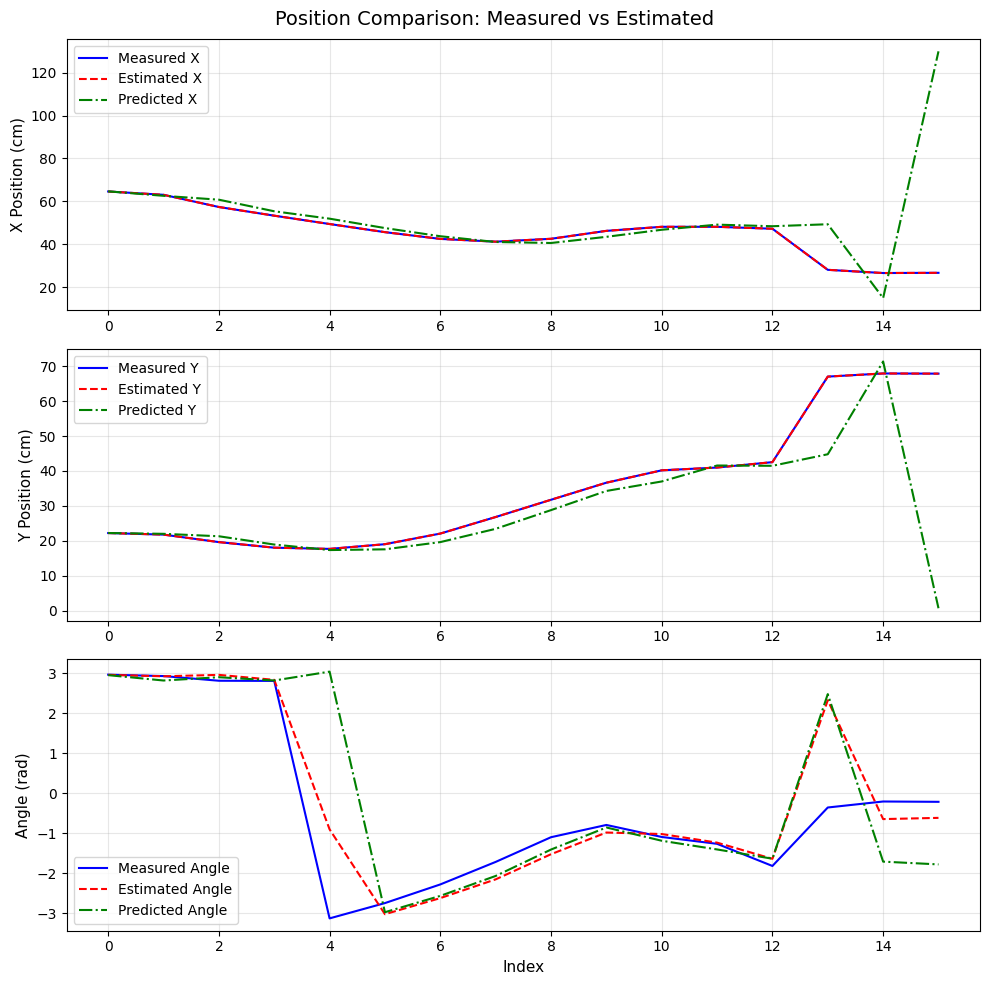

In [4]:
import asyncio
import main
await main.main()

## 5. Conclusion

We implemented the vision, global navigation, motion control, local avoidance, and filtering modules. The result is a functional system in which the Thymio robot reaches its goal while avoiding obstacles. This project helped us consolidate and apply the concepts learned in the Basics of Mobile Robotics course. We also improved our teamwork and used AI as a tool for testing and debugging, without relying on it to write the entire program. Finally, we made pragmatic compromises and adaptations to obtain a working implementation.

## 6. References

[1]: [OpenCV Librairy](http://docs.opencv.org/4.x/)

[2]: [Amit's A* Pages](https://theory.stanford.edu/~amitp/GameProgramming/Heuristics.html)

[3]: [EKF Wikipedia](https://en.wikipedia.org/wiki/Extended_Kalman_filter)